In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yosefesam","key":"d87991b71728ee8628681a14cc0624c0"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection
!unzip -q brain-mri-images-for-brain-tumor-detection.zip -d dataset

Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
  0% 0.00/15.1M [00:00<?, ?B/s]
100% 15.1M/15.1M [00:00<00:00, 1.04GB/s]


In [4]:
import os, shutil
import numpy as np
from sklearn.model_selection import train_test_split

base_dir = "dataset/brain_tumor_dataset"
split_dir = "dataset_split"

if not os.path.exists(split_dir):
    os.makedirs(split_dir + "/train/yes")
    os.makedirs(split_dir + "/train/no")
    os.makedirs(split_dir + "/val/yes")
    os.makedirs(split_dir + "/val/no")
    os.makedirs(split_dir + "/test/yes")
    os.makedirs(split_dir + "/test/no")

    for category in ["yes", "no"]:
        files = os.listdir(os.path.join(base_dir, category))
        train_files, test_files = train_test_split(files, test_size=0.2, random_state=42)
        train_files, val_files = train_test_split(train_files, test_size=0.2, random_state=42)

        for f in train_files:
            shutil.copy(os.path.join(base_dir, category, f), os.path.join(split_dir, "train", category))
        for f in val_files:
            shutil.copy(os.path.join(base_dir, category, f), os.path.join(split_dir, "val", category))
        for f in test_files:
            shutil.copy(os.path.join(base_dir, category, f), os.path.join(split_dir, "test", category))

print("✅ Dataset splitted successfully!")

✅ Dataset splitted successfully!


In [5]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    split_dir+"/train", target_size=(150,150), batch_size=32, class_mode="binary")

val_generator = val_datagen.flow_from_directory(
    split_dir+"/val", target_size=(150,150), batch_size=32, class_mode="binary")

test_generator = test_datagen.flow_from_directory(
    split_dir+"/test", target_size=(150,150), batch_size=32, class_mode="binary", shuffle=False)

Found 161 images belonging to 2 classes.
Found 41 images belonging to 2 classes.
Found 51 images belonging to 2 classes.


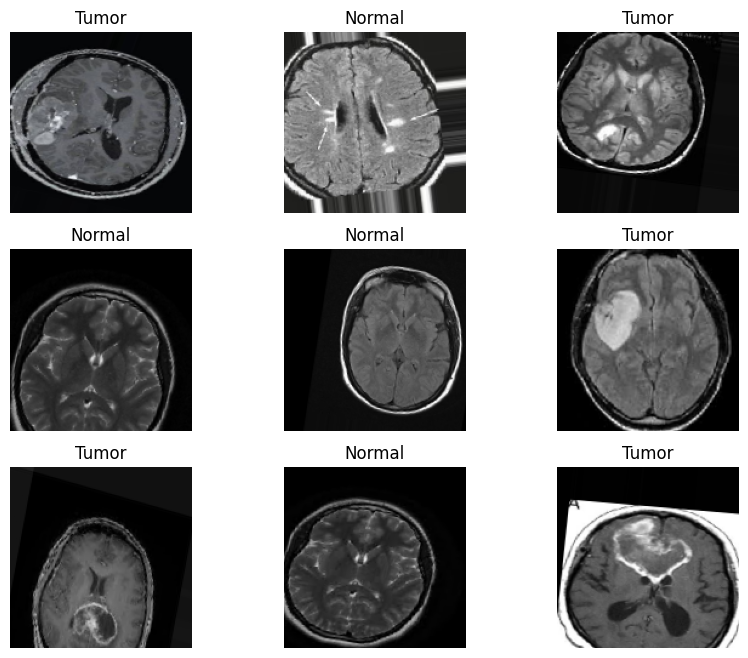

In [6]:
x_batch, y_batch = next(train_generator)
plt.figure(figsize=(10, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_batch[i])
    plt.title("Tumor" if y_batch[i] == 1 else "Normal")
    plt.axis("off")
plt.show()

In [7]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

base_model = VGG16(weights="imagenet", include_top=False, input_shape=(150,150,3))
base_model.trainable = False  # Freeze layers

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
model.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,763,521 (60.13 MB)

 Trainable params: 1,048,833 (4.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5505 - loss: 0.8435

6/6 ━━━━━━━━━━━━━━━━━━━━ 49s 8s/step - accuracy: 0.5446 - loss: 0.8444 - val_accuracy: 0.7073 - val_loss: 0.6227
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 45s 8s/step - accuracy: 0.5742 - loss: 0.6752 - val_accuracy: 0.6098 - val_loss: 0.6886
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5904 - loss: 0.8279

6/6 ━━━━━━━━━━━━━━━━━━━━ 47s 8s/step - accuracy: 0.5930 - loss: 0.8175 - val_accuracy: 0.7561 - val_loss: 0.5734
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 46s 8s/step - accuracy: 0.6633 - loss: 0.6713 - val_accuracy: 0.6341 - val_loss: 0.5744
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6162 - loss: 0.6688

6/6 ━━━━━━━━━━━━━━━━━━━━ 82s 8s/step - accuracy: 0.6116 - loss: 0.6737 - val_accuracy: 0.7561 - val_loss: 0.5592
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6664 - loss: 0.6129

6/6 ━━━━━━━━━━━━━━━━━━━━ 45s 8s/step - accuracy: 0.6724 - loss: 0.6097 - val_accuracy: 0.7561 - val_loss: 0.5582
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 47s 8s/step - accuracy: 0.6396 - loss: 0.6115 - val_accuracy: 0.7561 - val_loss: 0.5646
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 46s 8s/step - accuracy: 0.6289 - loss: 0.6075 - val_accuracy: 0.7805 - val_loss: 0.5767
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 48s 8s/step - accuracy: 0.7026 - loss: 0.5587 - val_accuracy: 0.7805 - val_loss: 0.5606
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7224 - loss: 0.5494

6/6 ━━━━━━━━━━━━━━━━━━━━ 45s 8s/step - accuracy: 0.7194 - loss: 0.5503 - val_accuracy: 0.7805 - val_loss: 0.5505
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6841 - loss: 0.6299

6/6 ━━━━━━━━━━━━━━━━━━━━ 46s 8s/step - accuracy: 0.6911 - loss: 0.6229 - val_accuracy: 0.7561 - val_loss: 0.5415
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 45s 8s/step - accuracy: 0.6421 - loss: 0.6211 - val_accuracy: 0.7073 - val_loss: 0.5415
Epoch 13/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 47s 8s/step - accuracy: 0.7208 - loss: 0.5311 - val_accuracy: 0.7561 - val_loss: 0.5473
Epoch 14/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 45s 8s/step - accuracy: 0.6729 - loss: 0.5615 - val_accuracy: 0.6829 - val_loss: 0.5448
Epoch 15/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 58s 10s/step - accuracy: 0.7631 - loss: 0.4788 - val_accuracy: 0.6829 - val_loss: 0.5597
Epoch 16/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 74s 9s/step - accuracy: 0.7340 - loss: 0.4919 - val_accuracy: 0.6829 - val_loss: 0.5462


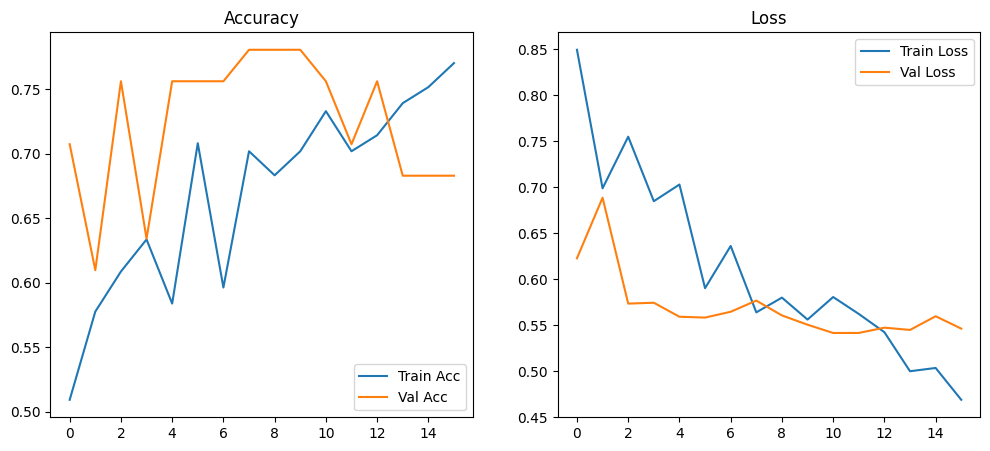

In [11]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(acc, label="Train Acc")
plt.plot(val_acc, label="Val Acc")
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.legend(); plt.title("Loss")
plt.show()

In [14]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 5s/step - accuracy: 0.7625 - loss: 0.4732
Test Accuracy: 0.7843


In [17]:
model.save("brain_tumor_model.keras")
print(" Model saved successfully!")

 Model saved successfully!


In [48]:
!pip install streamlit pyngrok

In [49]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image

# Load the trained model
model = tf.keras.models.load_model("brain_tumor_model.keras")

# Streamlit app design
st.set_page_config(page_title="Brain Tumor Detector", page_icon="🧠", layout="centered")

st.markdown(
    """
    <style>
        body {
            background-color: black;
            color: white;
        }
        .stApp {
            background-color: #000000;
        }
        h1, h2, h3 {
            color: #00FFAA;
            text-align: center;
        }
    </style>
    """,
    unsafe_allow_html=True,
)

st.title("🧠 Brain Tumor Detection App")
st.write("Upload an MRI image and let the AI model predict if a brain tumor is present.")

uploaded_file = st.file_uploader("📤 Upload an MRI image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:

    st.image(uploaded_file, caption="Uploaded MRI Image", use_column_width=True)

    img = image.load_img(uploaded_file, target_size=(150, 150))
    img_array = image.img_to_array(img)

    if img_array.shape[-1] == 1:
        img_array = np.repeat(img_array, 3, axis=-1)

    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        st.markdown("<h2 style='color: red;'>⚠️ Brain Tumor Detected</h2>", unsafe_allow_html=True)
    else:
        st.markdown("<h2 style='color: lime;'>✅ No Brain Tumor Detected</h2>", unsafe_allow_html=True)



Overwriting app.py


In [57]:
!rm -rf ~/.ngrok2
!pkill ngrok

In [58]:
!pip install --upgrade pyngrok


In [59]:
from pyngrok import ngrok

ngrok.set_auth_token("32n85CRlq11fbYTo9fvAc0RmKsQ_7PqFFBPeQNpMkCsnVBEAe")



In [61]:
!python app.py

2025-09-16 18:01:58.496056: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758045718.531345   26636 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758045718.542034   26636 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758045718.568424   26636 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1758045718.568468   26636 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1758045718.568477   26636 computation_placer.cc:177] computation placer alr

In [62]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print("🌍 Public URL:", public_url)



🌍 Public URL: NgrokTunnel: "https://647949a4749f.ngrok-free.app" -> "http://localhost:8501"
